In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 400
import seaborn as sns

In [3]:
df = pd.read_csv("realistic_synthetic_chat_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   conversation_id  500 non-null    int64 
 1   patient_message  500 non-null    object
 2   doctor_response  500 non-null    object
 3   intent           500 non-null    object
 4   sentiment        500 non-null    object
 5   summary          500 non-null    object
 6   key_points       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [4]:
df.columns

Index(['conversation_id', 'patient_message', 'doctor_response', 'intent',
       'sentiment', 'summary', 'key_points'],
      dtype='object')

In [5]:
df['intent'].value_counts()

intent
general_questions      97
request_appointment    95
discuss_symptoms       80
follow_up              77
complaint              76
ask_prescription       75
Name: count, dtype: int64

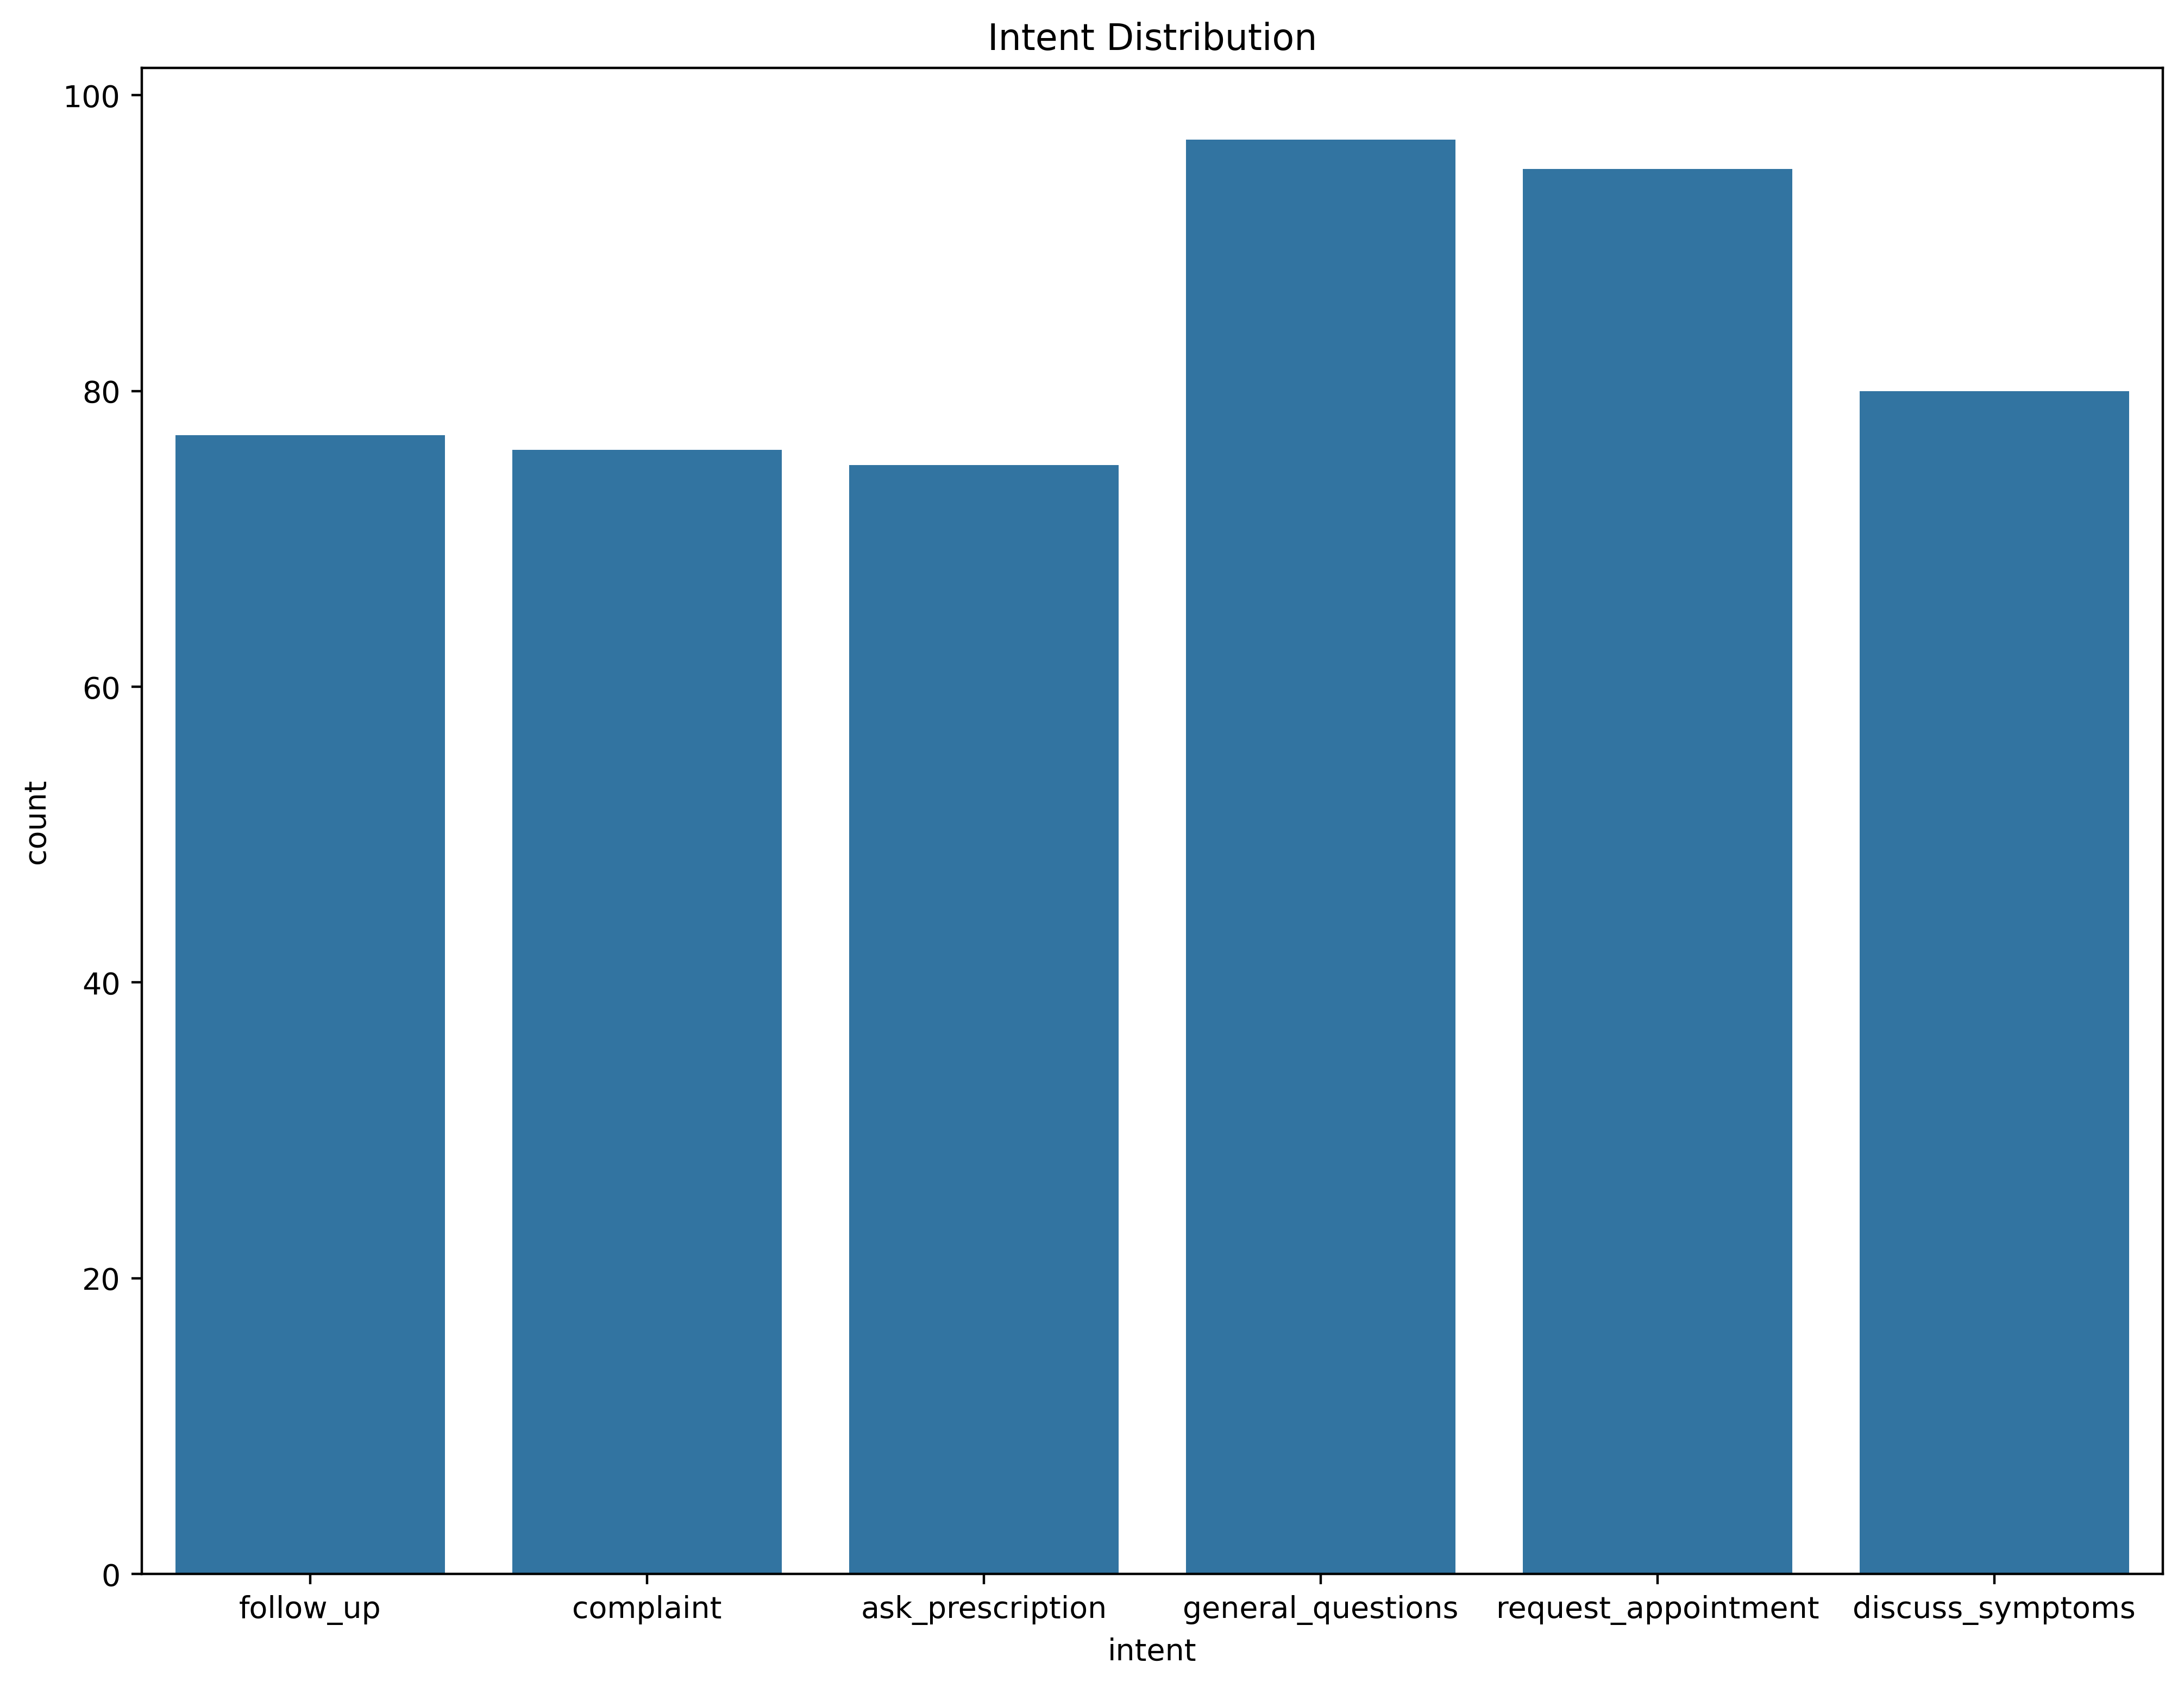

In [6]:
plt.figure(figsize = (12,9))
sns.countplot(data = df, x = "intent")
plt.title("Intent Distribution")
plt.xticks(rotation=0)
plt.show()

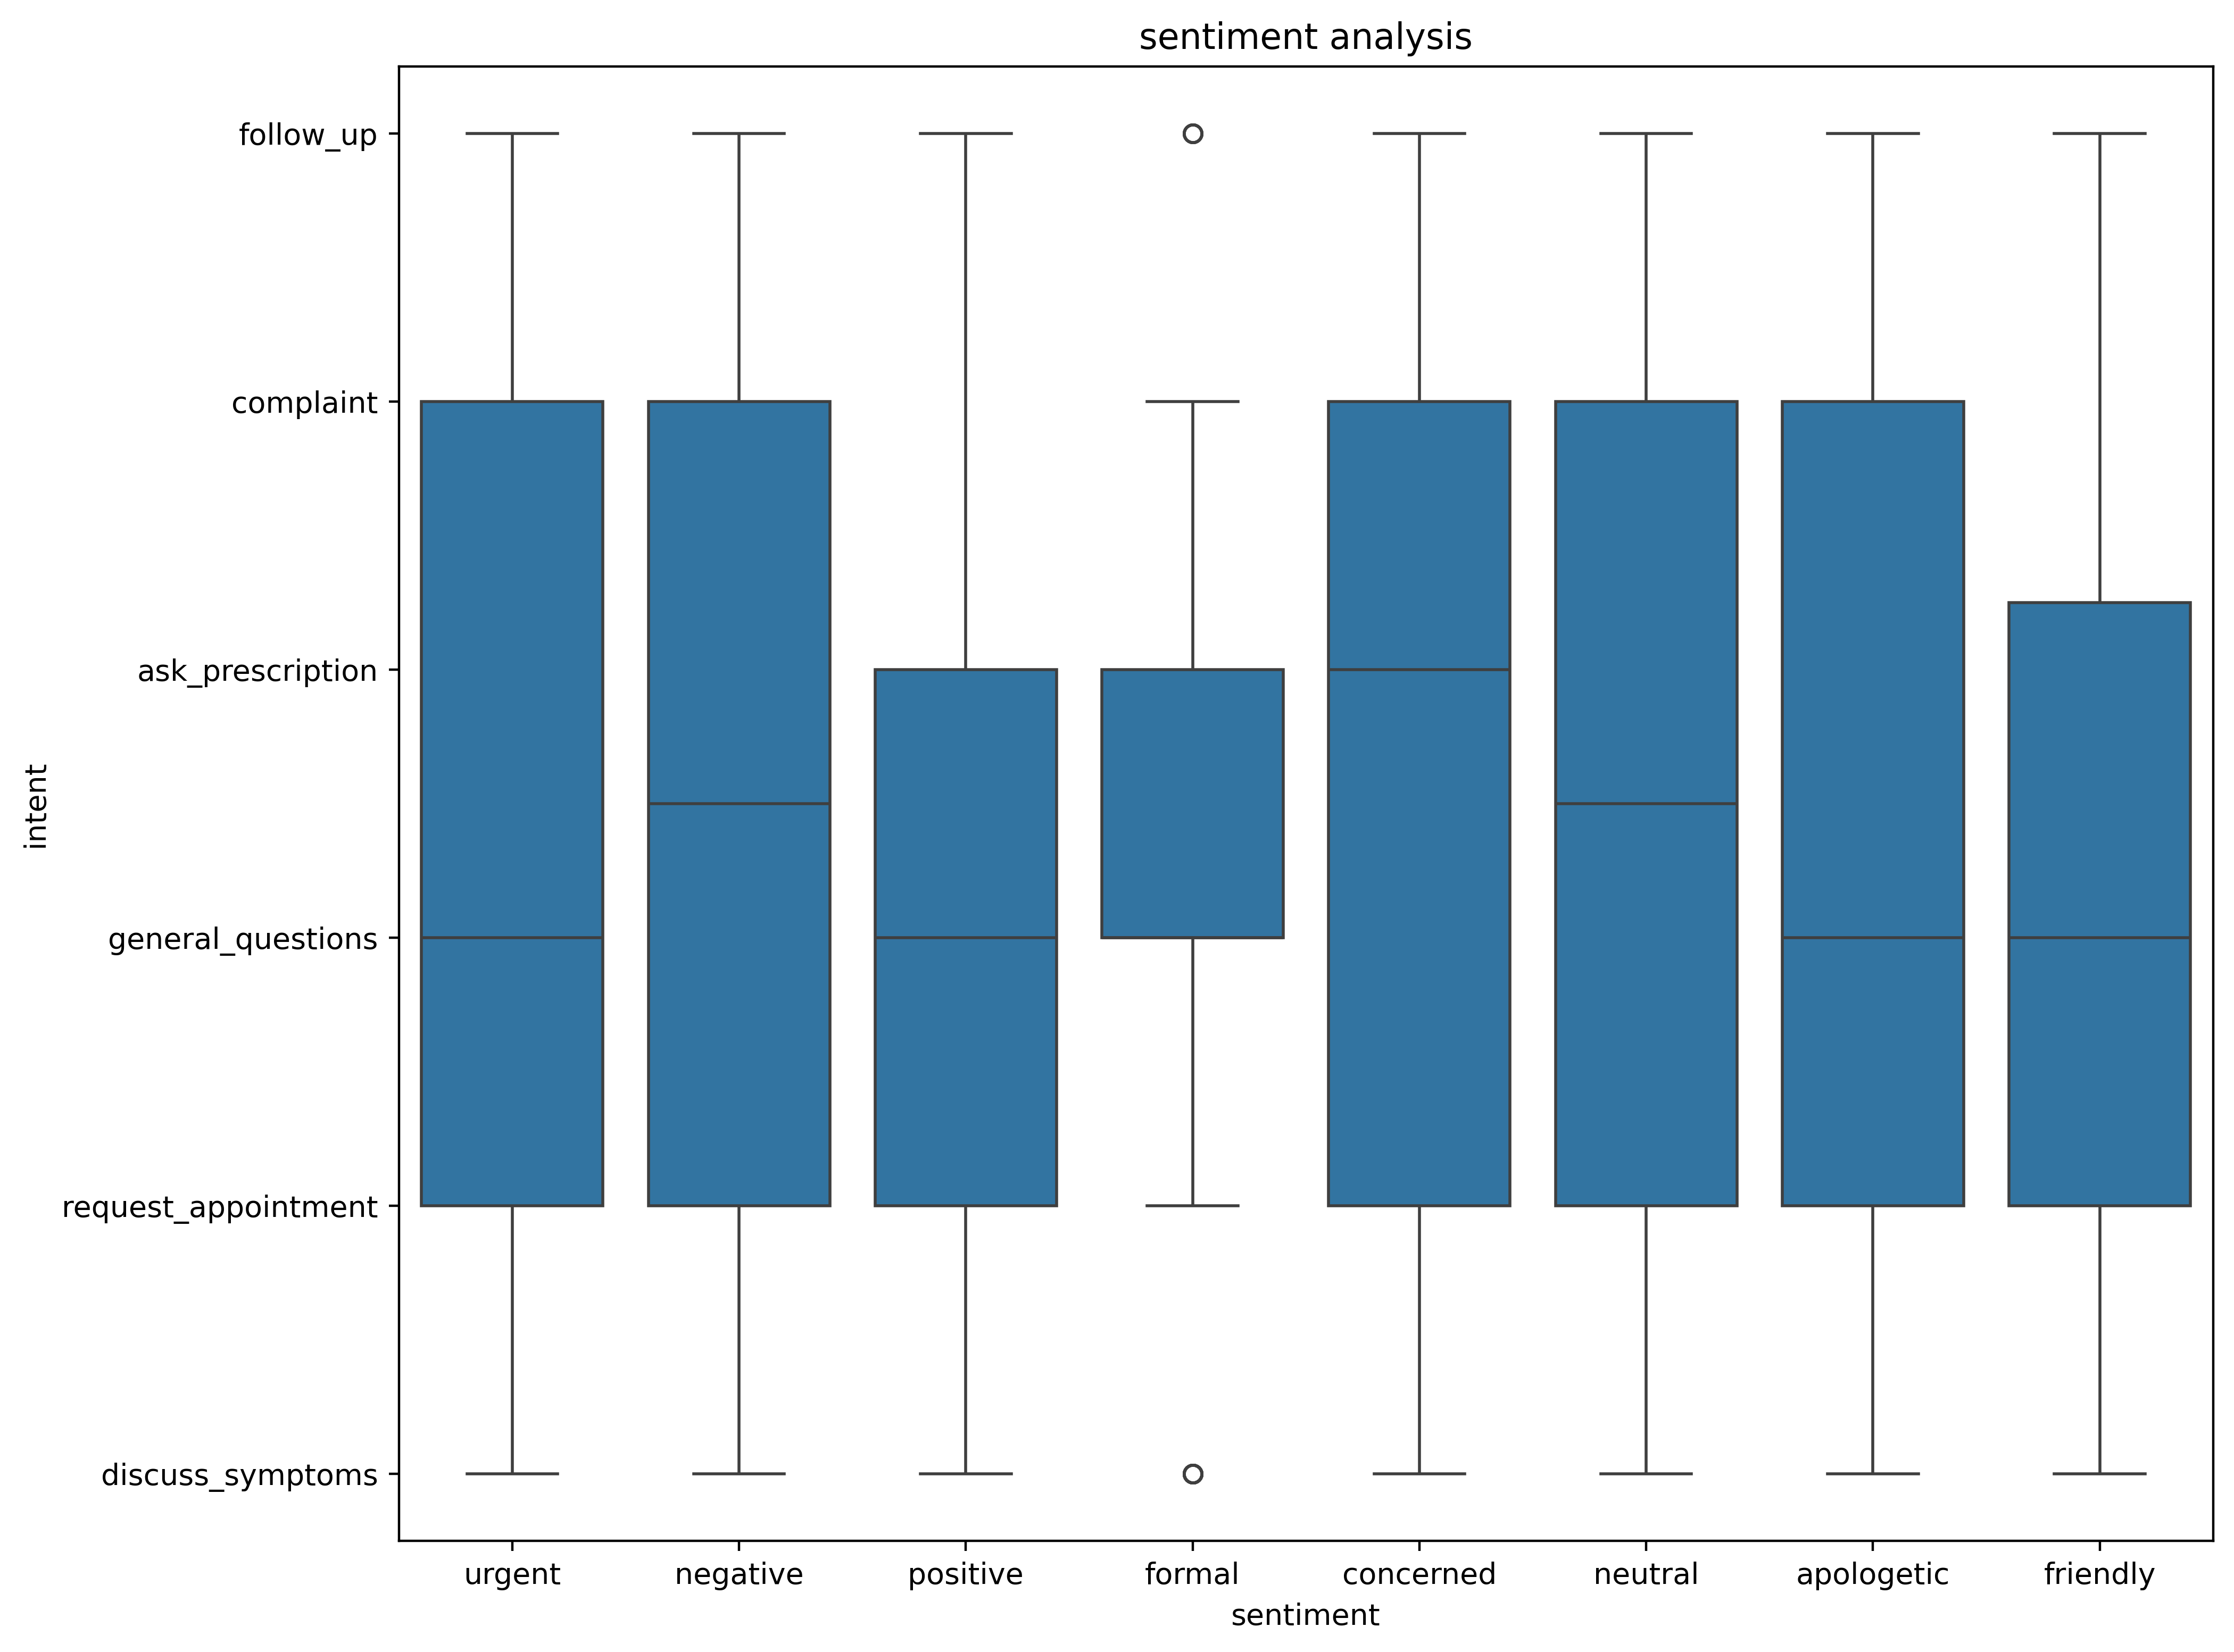

In [7]:
plt.figure(figsize=(11,9))
sns.boxplot(data = df, x = 'sentiment', y = "intent")
plt.title("sentiment analysis")
plt.show()

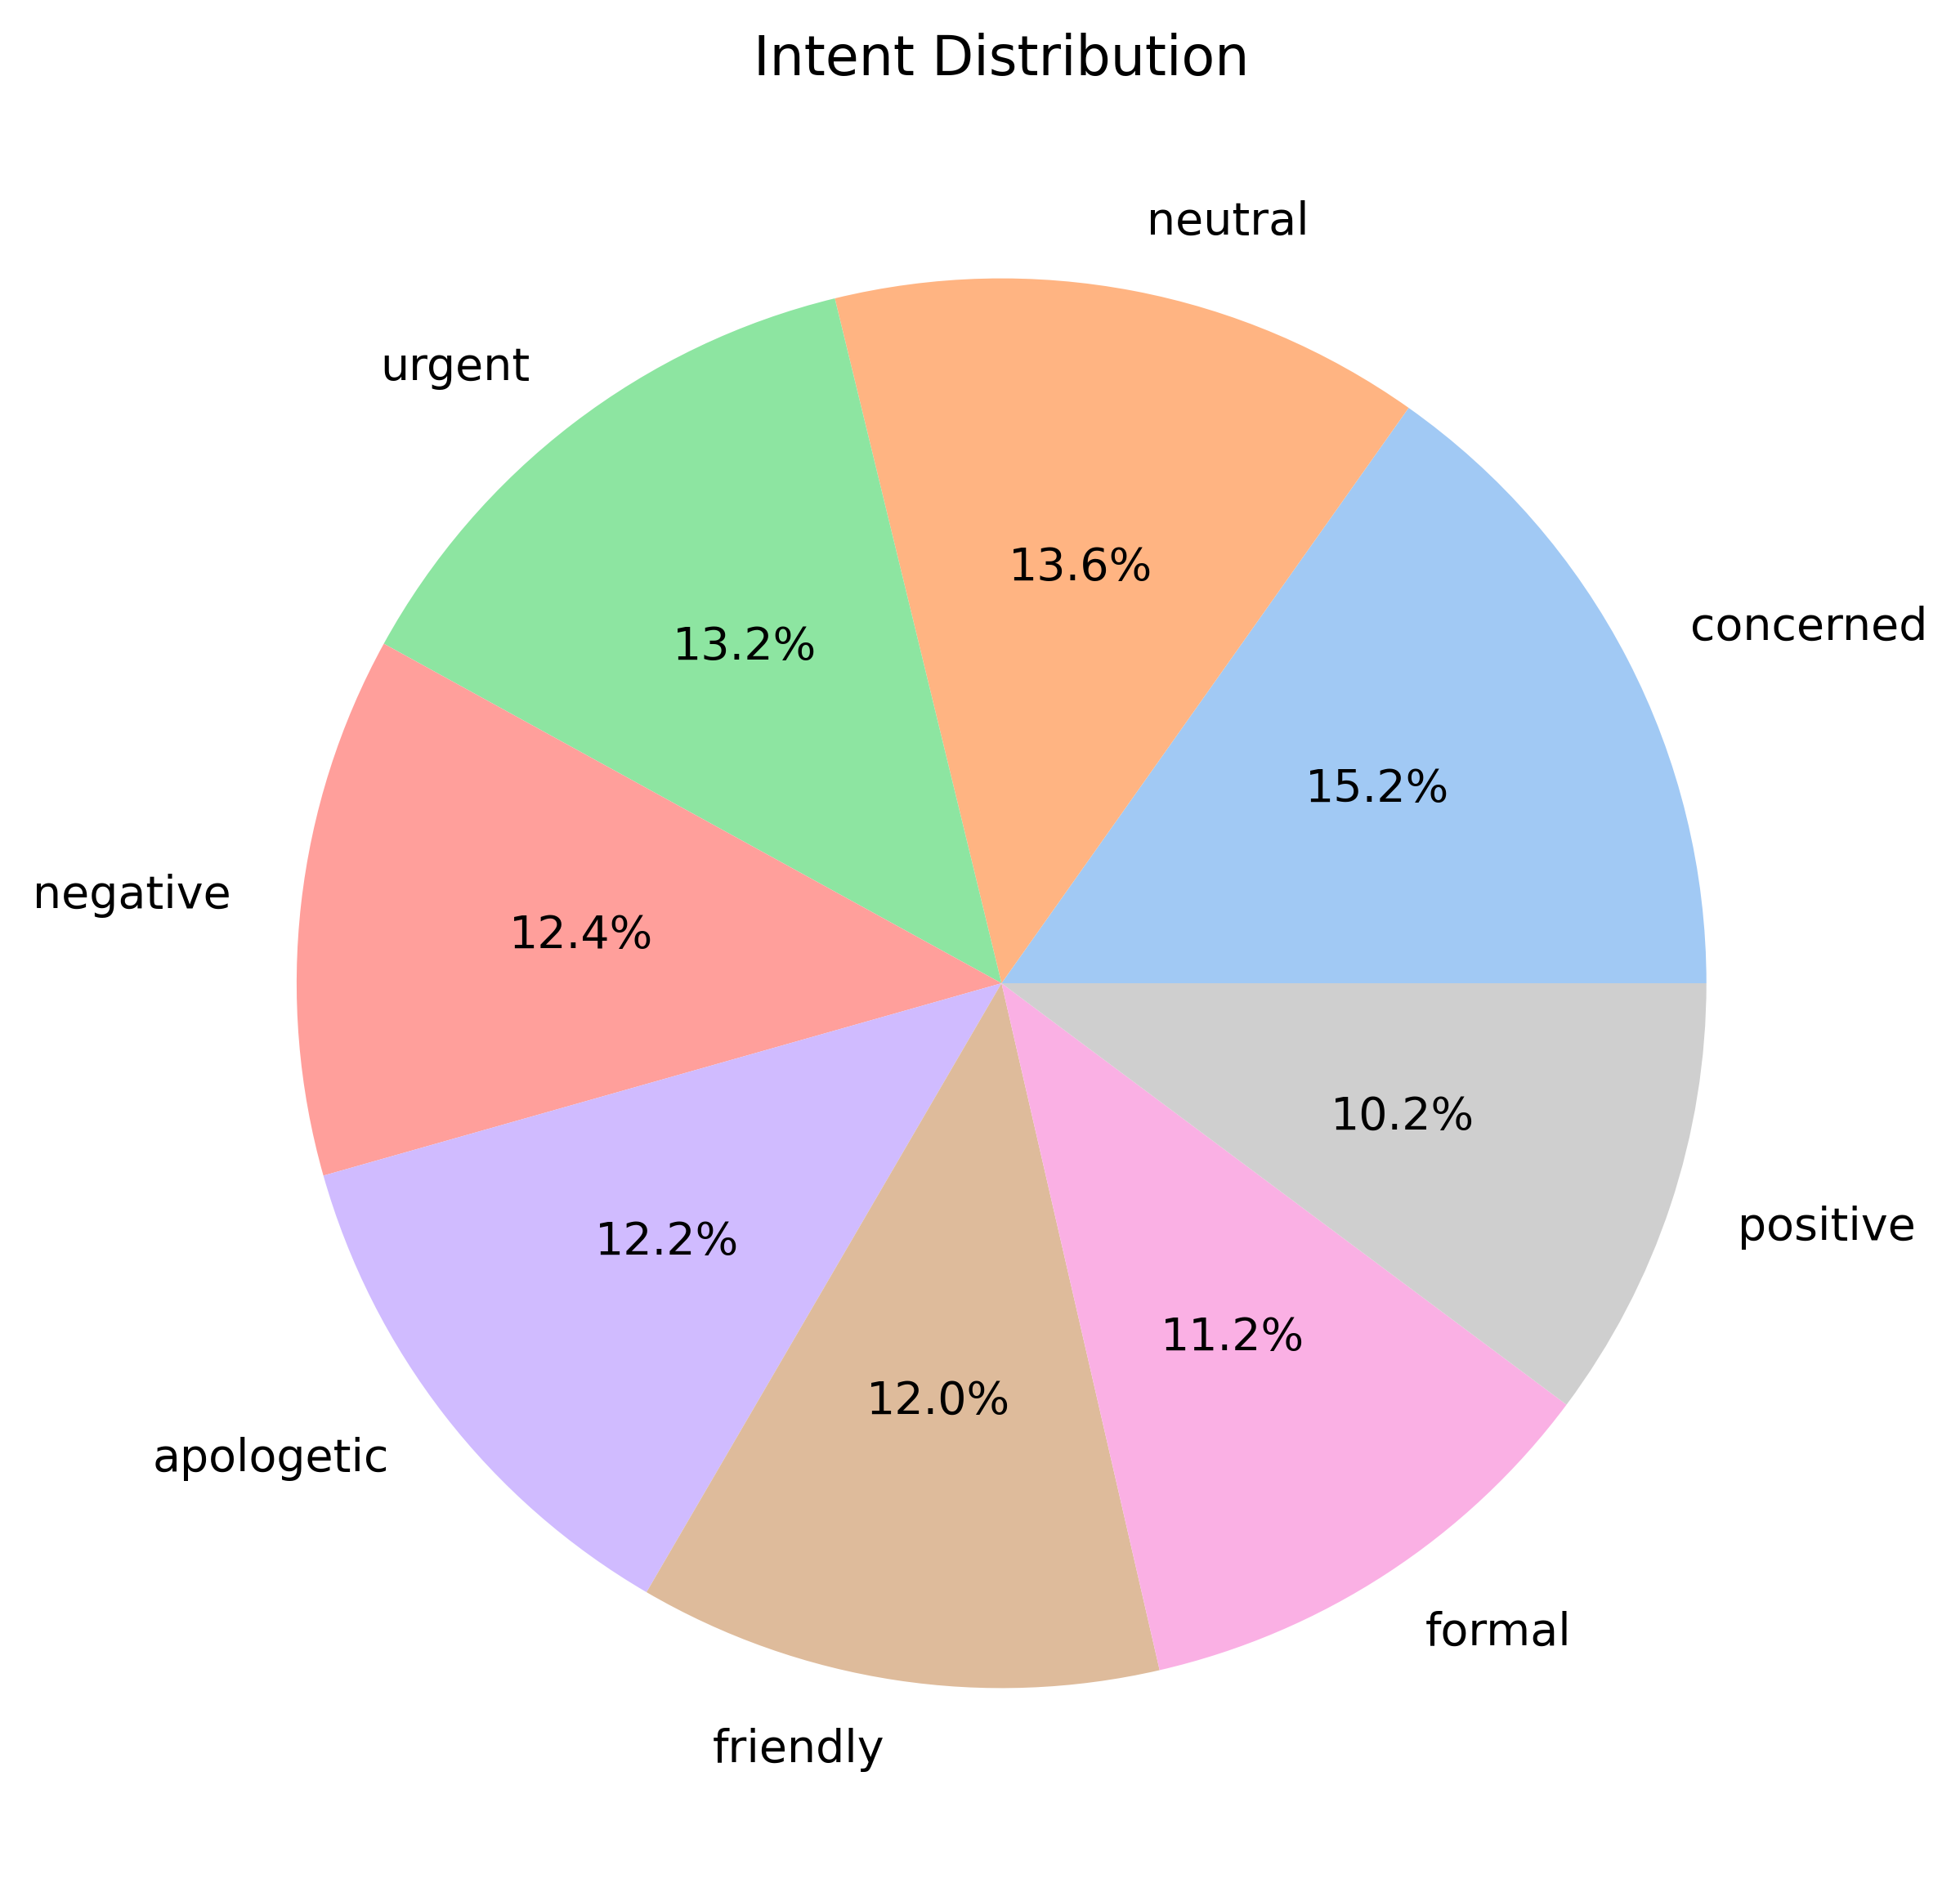

In [8]:
plt.figure(figsize = (11,7))
plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index, 
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Intent Distribution')
plt.show()

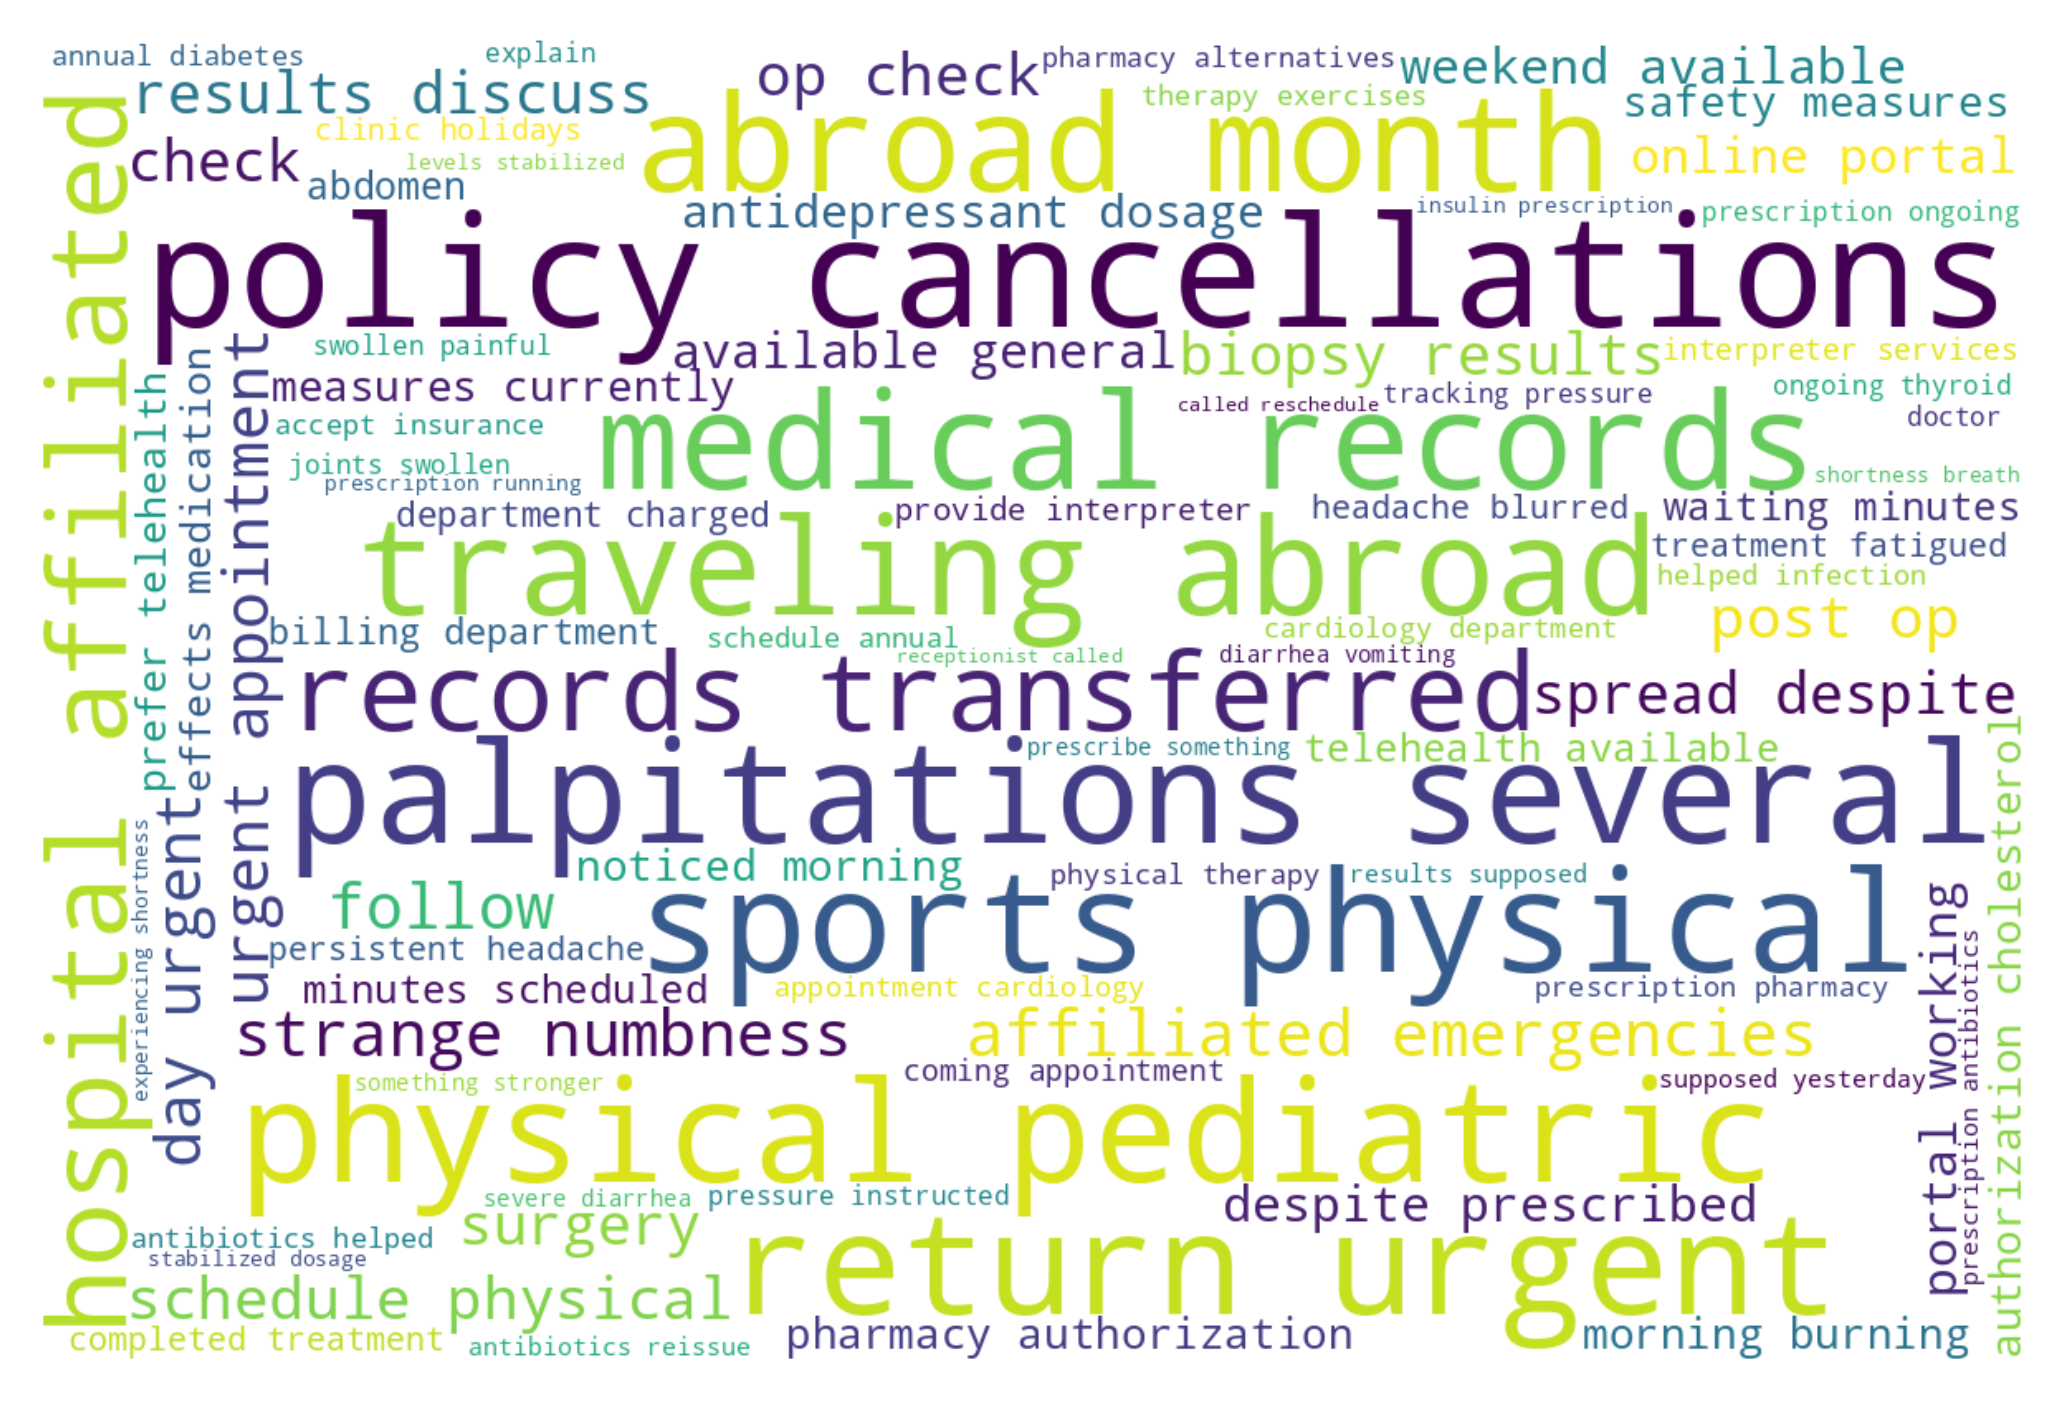

In [9]:
from wordcloud import WordCloud
key_points_text = ' '.join(df['key_points'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(key_points_text)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

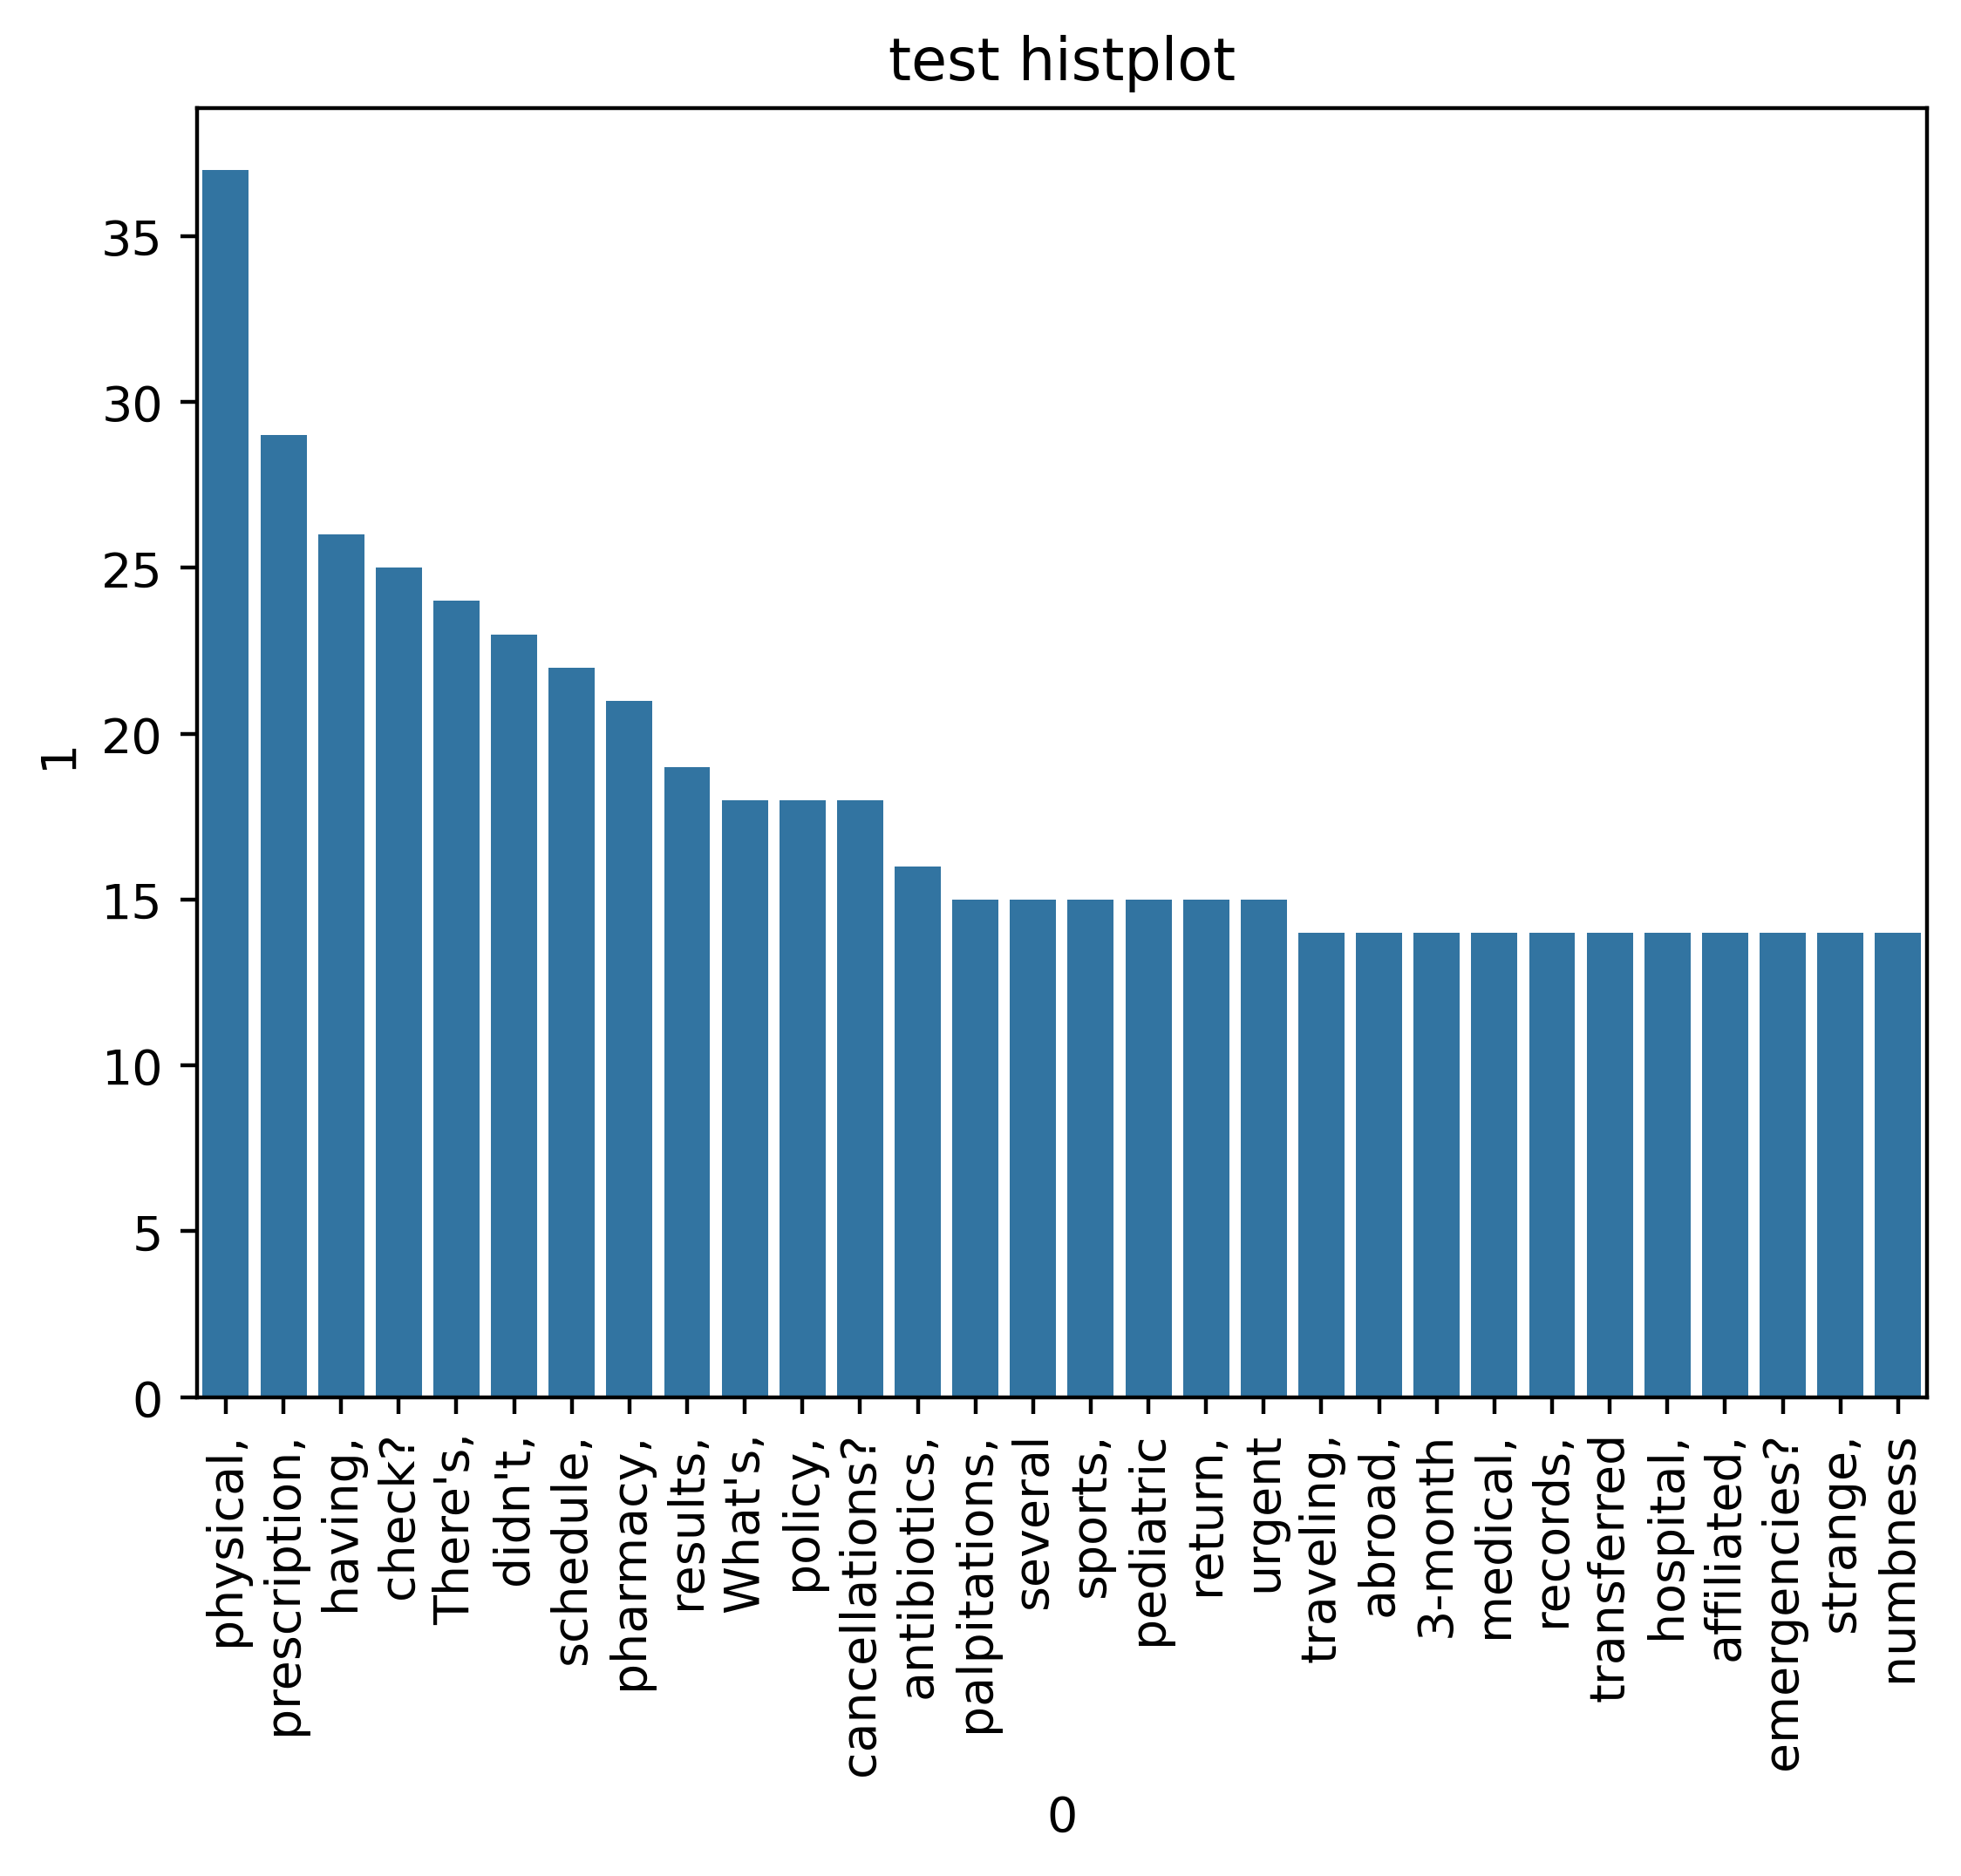

In [10]:
from collections import Counter
cunt_word = [ word  for i in df['key_points'].to_list()  for word in i.split()  ]
sns.barplot(x = pd.DataFrame(Counter(cunt_word).most_common(30))[0], y = pd.DataFrame(Counter(cunt_word).most_common(30))[1])
plt.title("test histplot")
plt.xticks(rotation = 'vertical')
plt.show()

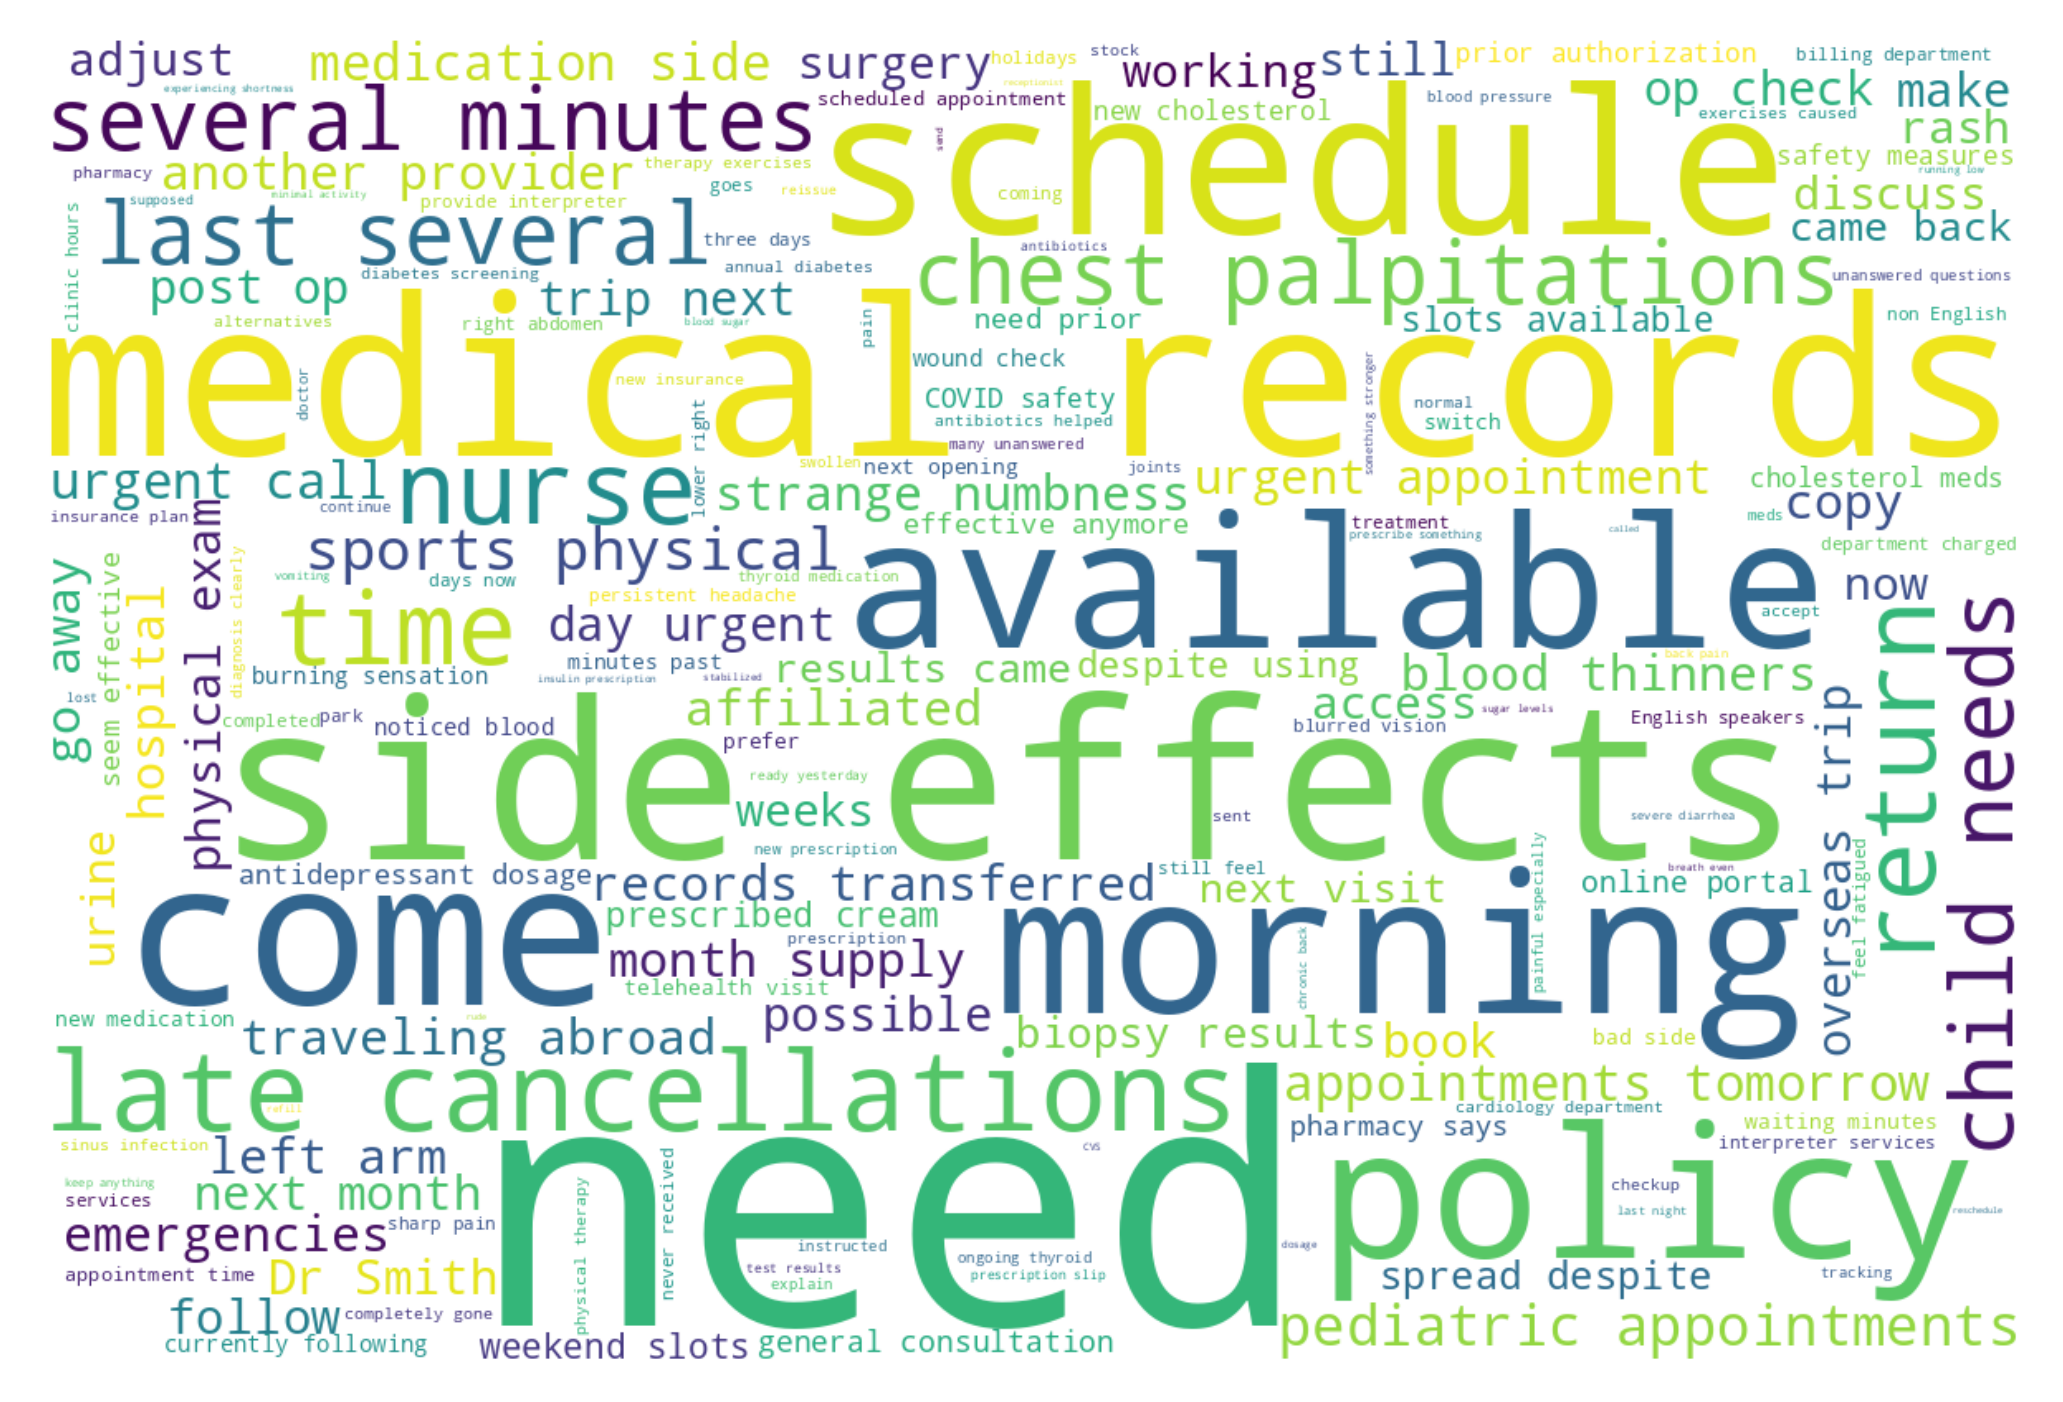

In [11]:
from wordcloud import WordCloud
patient_message = ' '.join(df['patient_message'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(patient_message)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

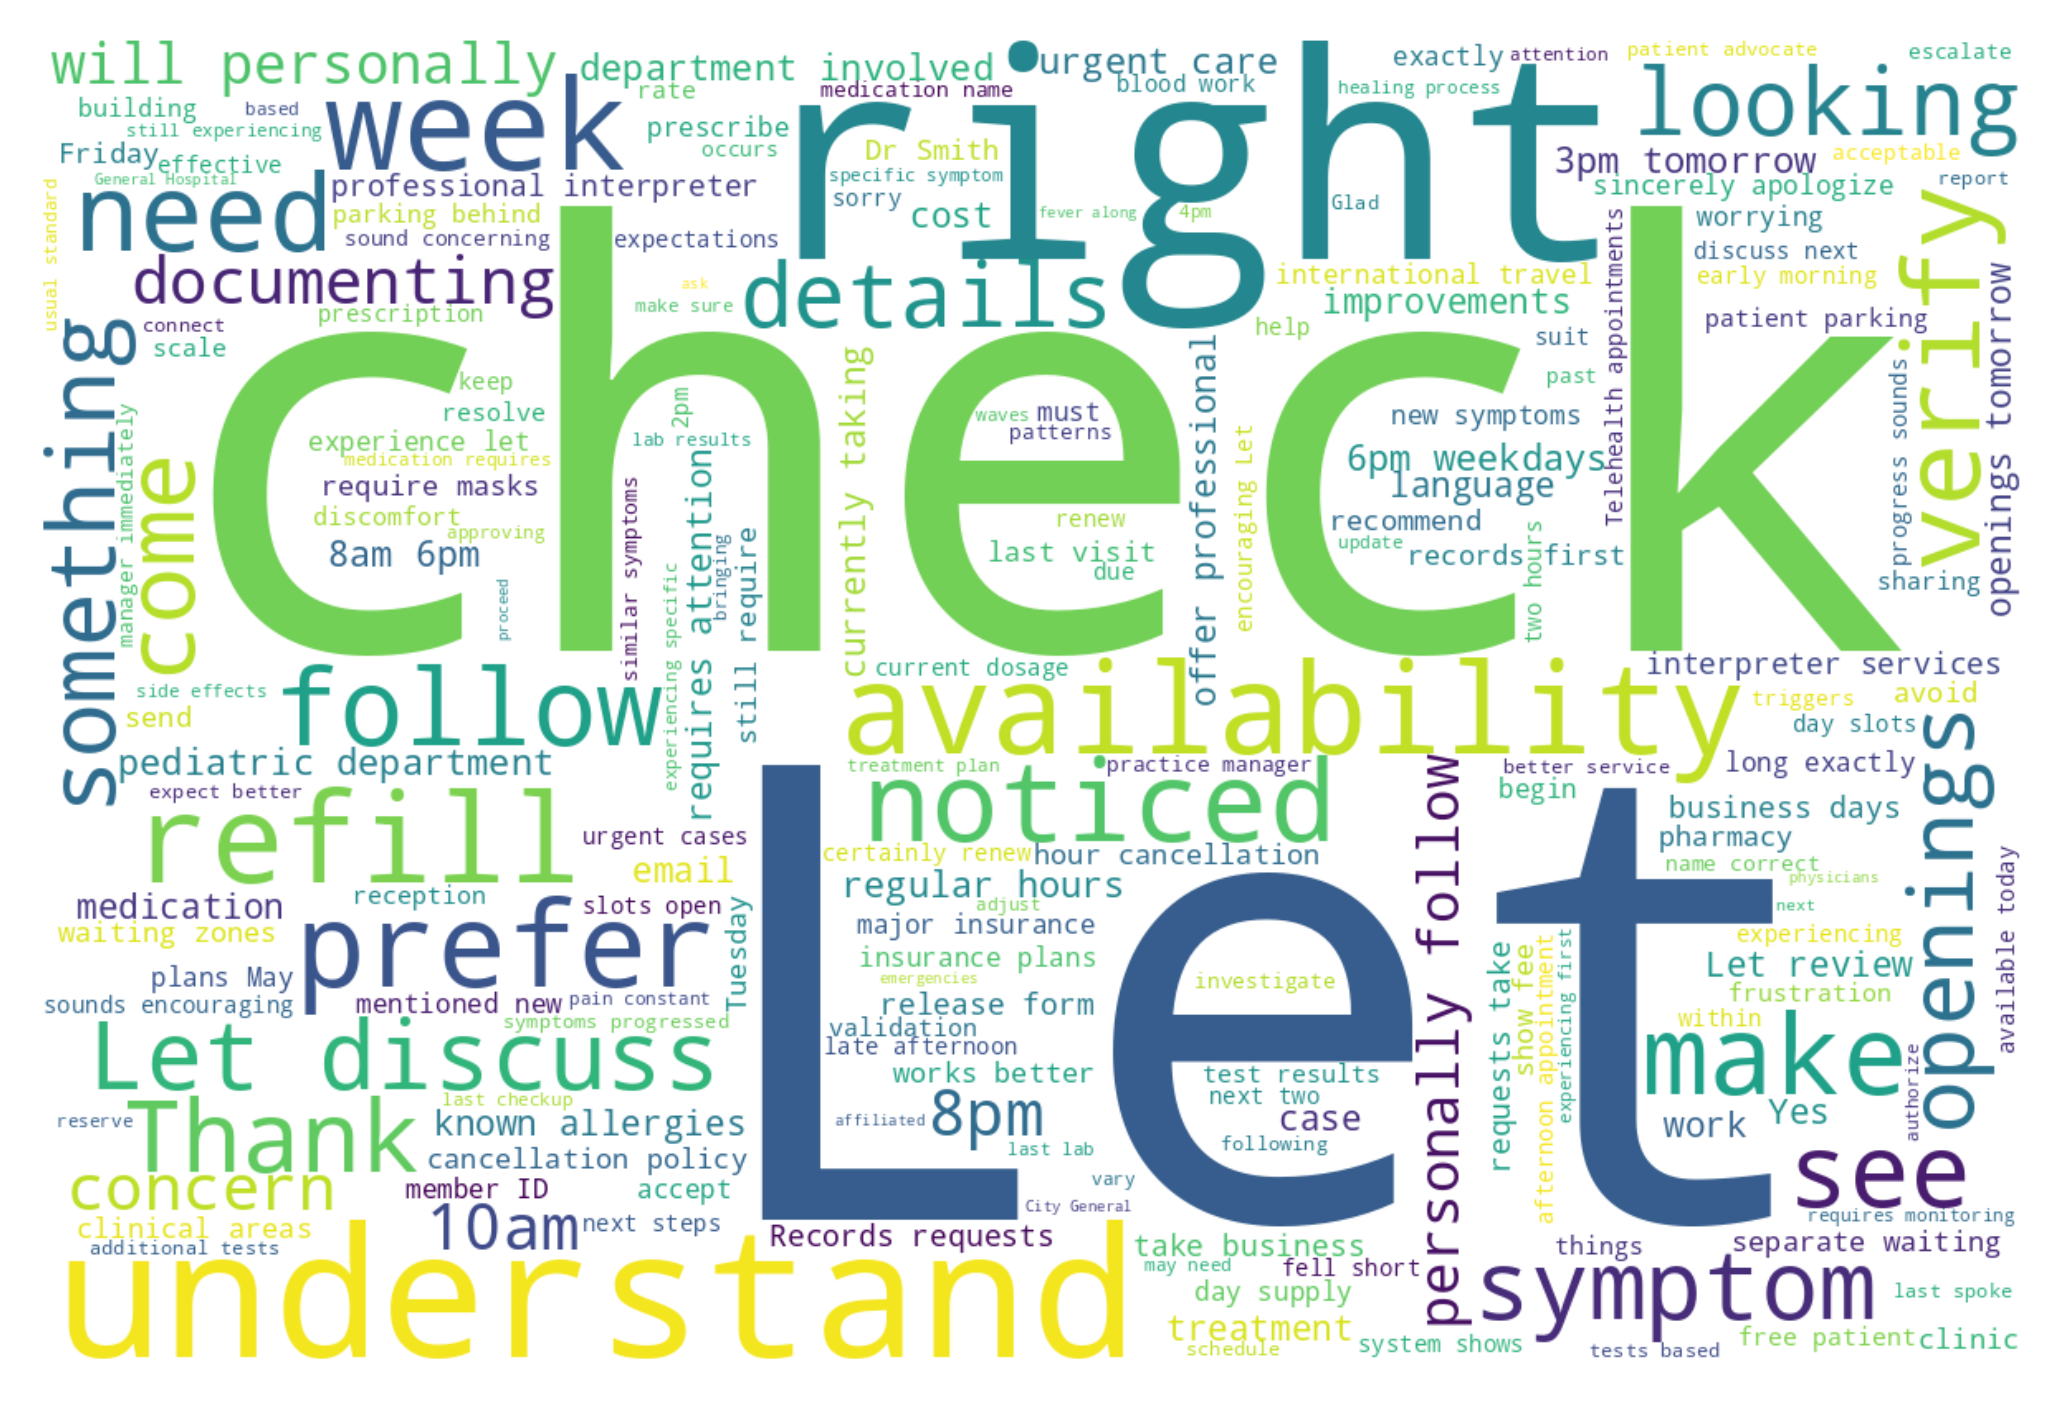

In [12]:
from wordcloud import WordCloud
doctor_response = ' '.join(df['doctor_response'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(doctor_response)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

In [13]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\arfit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arfit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\arfit/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
import re 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [22]:
df.head()

,conversation_id,patient_message,doctor_response,intent,sentiment,summary,key_points
0,1,The biopsy results came back - can we discuss ...,"Based on your update, we may need to adjust yo...",follow_up,urgent,Patient followed up regarding previous consult...,"biopsy, results, discuss"
1,2,The billing department charged me for services...,Thank you for bringing this to our attention. ...,complaint,negative,Patient reported dissatisfaction or issues.,"billing, department, charged"
2,3,I completed the treatment but still feel fatig...,Let's review your case. What improvements have...,follow_up,positive,Patient followed up regarding previous consult...,"completed, treatment, fatigued"
3,4,I'm traveling abroad and need a 3-month supply...,Let me verify - you need a refill for [medicat...,ask_prescription,formal,Patient asked for medication renewal or advice.,"traveling, abroad, 3-month"
4,5,The rash has spread despite using the prescrib...,You mentioned new symptoms - when exactly did ...,follow_up,concerned,Patient followed up regarding previous consult...,"spread, despite, prescribed"


In [23]:
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import joblib 

C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
req_df = df[["patient_message","intent","sentiment"]]
req_df.dropna()
req_df.head()

,patient_message,intent,sentiment
0,The biopsy results came back - can we discuss ...,follow_up,urgent
1,The billing department charged me for services...,complaint,negative
2,I completed the treatment but still feel fatig...,follow_up,positive
3,I'm traveling abroad and need a 3-month supply...,ask_prescription,formal
4,The rash has spread despite using the prescrib...,follow_up,concerned


In [27]:
it_le = LabelEncoder()
st_le = LabelEncoder()
req_df['intent_label'] = it_le.fit_transform(df['intent'])
req_df['sentiment_label'] = st_le.fit_transform(df['sentiment'])

C:\Users\arfit\AppData\Local\Temp\ipykernel_5468\1478640520.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  req_df['intent_label'] = it_le.fit_transform(df['intent'])
C:\Users\arfit\AppData\Local\Temp\ipykernel_5468\1478640520.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  req_df['sentiment_label'] = st_le.fit_transform(df['sentiment'])


In [29]:
req_df

,patient_message,intent,sentiment,intent_label,sentiment_label
0,The biopsy results came back - can we discuss ...,follow_up,urgent,3,7
1,The billing department charged me for services...,complaint,negative,1,4
2,I completed the treatment but still feel fatig...,follow_up,positive,3,6
3,I'm traveling abroad and need a 3-month supply...,ask_prescription,formal,0,2
4,The rash has spread despite using the prescrib...,follow_up,concerned,3,1
...,...,...,...,...,...
495,Which hospital are you affiliated with for eme...,general_questions,positive,4,6
496,What's your policy on late cancellations?,general_questions,concerned,4,1
497,The nurse didn't return my urgent call about m...,complaint,negative,1,4
498,I've been tracking my blood pressure as instru...,follow_up,negative,3,4


In [32]:
joblib.dump(it_le,"intent_label_encoded.pkl")
req_df[['intent','intent_label']].drop_duplicates().sort_values('intent_label')
joblib.dump(st_le,"sentiment_label_encoded.pkl")
req_df[['sentiment','sentiment_label']].drop_duplicates().sort_values('sentiment_label')
print(req_df[['sentiment','sentiment_label']].drop_duplicates().sort_values('sentiment_label'))
print(req_df[['intent','intent_label']].drop_duplicates().sort_values('intent_label'))

     sentiment  sentiment_label
8   apologetic                0
4    concerned                1
3       formal                2
11    friendly                3
1     negative                4
5      neutral                5
2     positive                6
0       urgent                7
                 intent  intent_label
3      ask_prescription             0
1             complaint             1
12     discuss_symptoms             2
0             follow_up             3
5     general_questions             4
6   request_appointment             5


In [35]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [36]:
def intent_tokenis(example):
    tokens = tokenizer(example['patient_message'], truncation=True, padding="max_length", max_length=128)
    tokens["labels"] = example["intent_label"]
    return tokens

In [37]:
dataset = Dataset.from_pandas(req_df[['patient_message', 'intent_label','sentiment_label']])
dataset = dataset.train_test_split(test_size=0.2)
dataset = dataset.map(intent_tokenis, batched=True)

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2487.40 examples/s]


In [62]:
def sentiment_tokenis(example):
    tokens = tokenizer(example['patient_message'], truncation=True, padding="max_length", max_length=128)
    tokens["labels"] = example["sentiment_label"]
    return tokens

In [64]:
dataset = Dataset.from_pandas(req_df[['patient_message', 'intent_label','sentiment_label']])
dataset = dataset.train_test_split(test_size=0.2)
dataset = dataset.map(sentiment_tokenis, batched=True)

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2505.95 examples/s]


In [46]:
intent_labels = req_df['intent_label'].nunique()

intent_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=intent_labels)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [66]:
sentiment_labels = req_df['sentiment_label'].nunique()
sentiment_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=sentiment_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
)


In [50]:
#  Define Metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="weighted")
    }


In [52]:
# INTENT MODEL TRAINING
intent_trainer = Trainer(
    model=intent_model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

intent_trainer.train()

Step,Training Loss


TrainOutput(global_step=150, training_loss=0.3173754628499349, metrics={'train_runtime': 355.7284, 'train_samples_per_second': 3.373, 'train_steps_per_second': 0.422, 'total_flos': 78936151449600.0, 'train_loss': 0.3173754628499349, 'epoch': 3.0})

In [54]:
intent_trainer.save_model()

In [68]:
# SENTIMENT MODEL TRAINING
sentiment_trainer = Trainer(
    model=sentiment_model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

sentiment_trainer.train()

Step,Training Loss


TrainOutput(global_step=150, training_loss=2.07403564453125, metrics={'train_runtime': 341.3239, 'train_samples_per_second': 3.516, 'train_steps_per_second': 0.439, 'total_flos': 78937568870400.0, 'train_loss': 2.07403564453125, 'epoch': 3.0})

In [70]:
sentiment_trainer.save_model()

In [60]:
# Evaluate
intent_trainer.evaluate()
# Optional: Classification Report
preds_output = intent_trainer.predict(dataset['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=it_le.classes_))


                     precision    recall  f1-score   support

   ask_prescription       1.00      1.00      1.00        14
          complaint       1.00      1.00      1.00        11
   discuss_symptoms       1.00      1.00      1.00        19
          follow_up       1.00      1.00      1.00        19
  general_questions       1.00      1.00      1.00        23
request_appointment       1.00      1.00      1.00        14

           accuracy                           1.00       100
          macro avg       1.00      1.00      1.00       100
       weighted avg       1.00      1.00      1.00       100



In [72]:
# Evaluate
sentiment_trainer.evaluate()
# Optional: Classification Report
preds_output = sentiment_trainer.predict(dataset['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=st_le.classes_))


              precision    recall  f1-score   support

  apologetic       0.20      0.14      0.17         7
   concerned       0.00      0.00      0.00        21
      formal       0.00      0.00      0.00        15
    friendly       0.00      0.00      0.00         7
    negative       0.00      0.00      0.00        14
     neutral       0.12      0.64      0.20        14
    positive       0.00      0.00      0.00         8
      urgent       0.06      0.07      0.06        14

    accuracy                           0.11       100
   macro avg       0.05      0.11      0.05       100
weighted avg       0.04      0.11      0.05       100



C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (6).

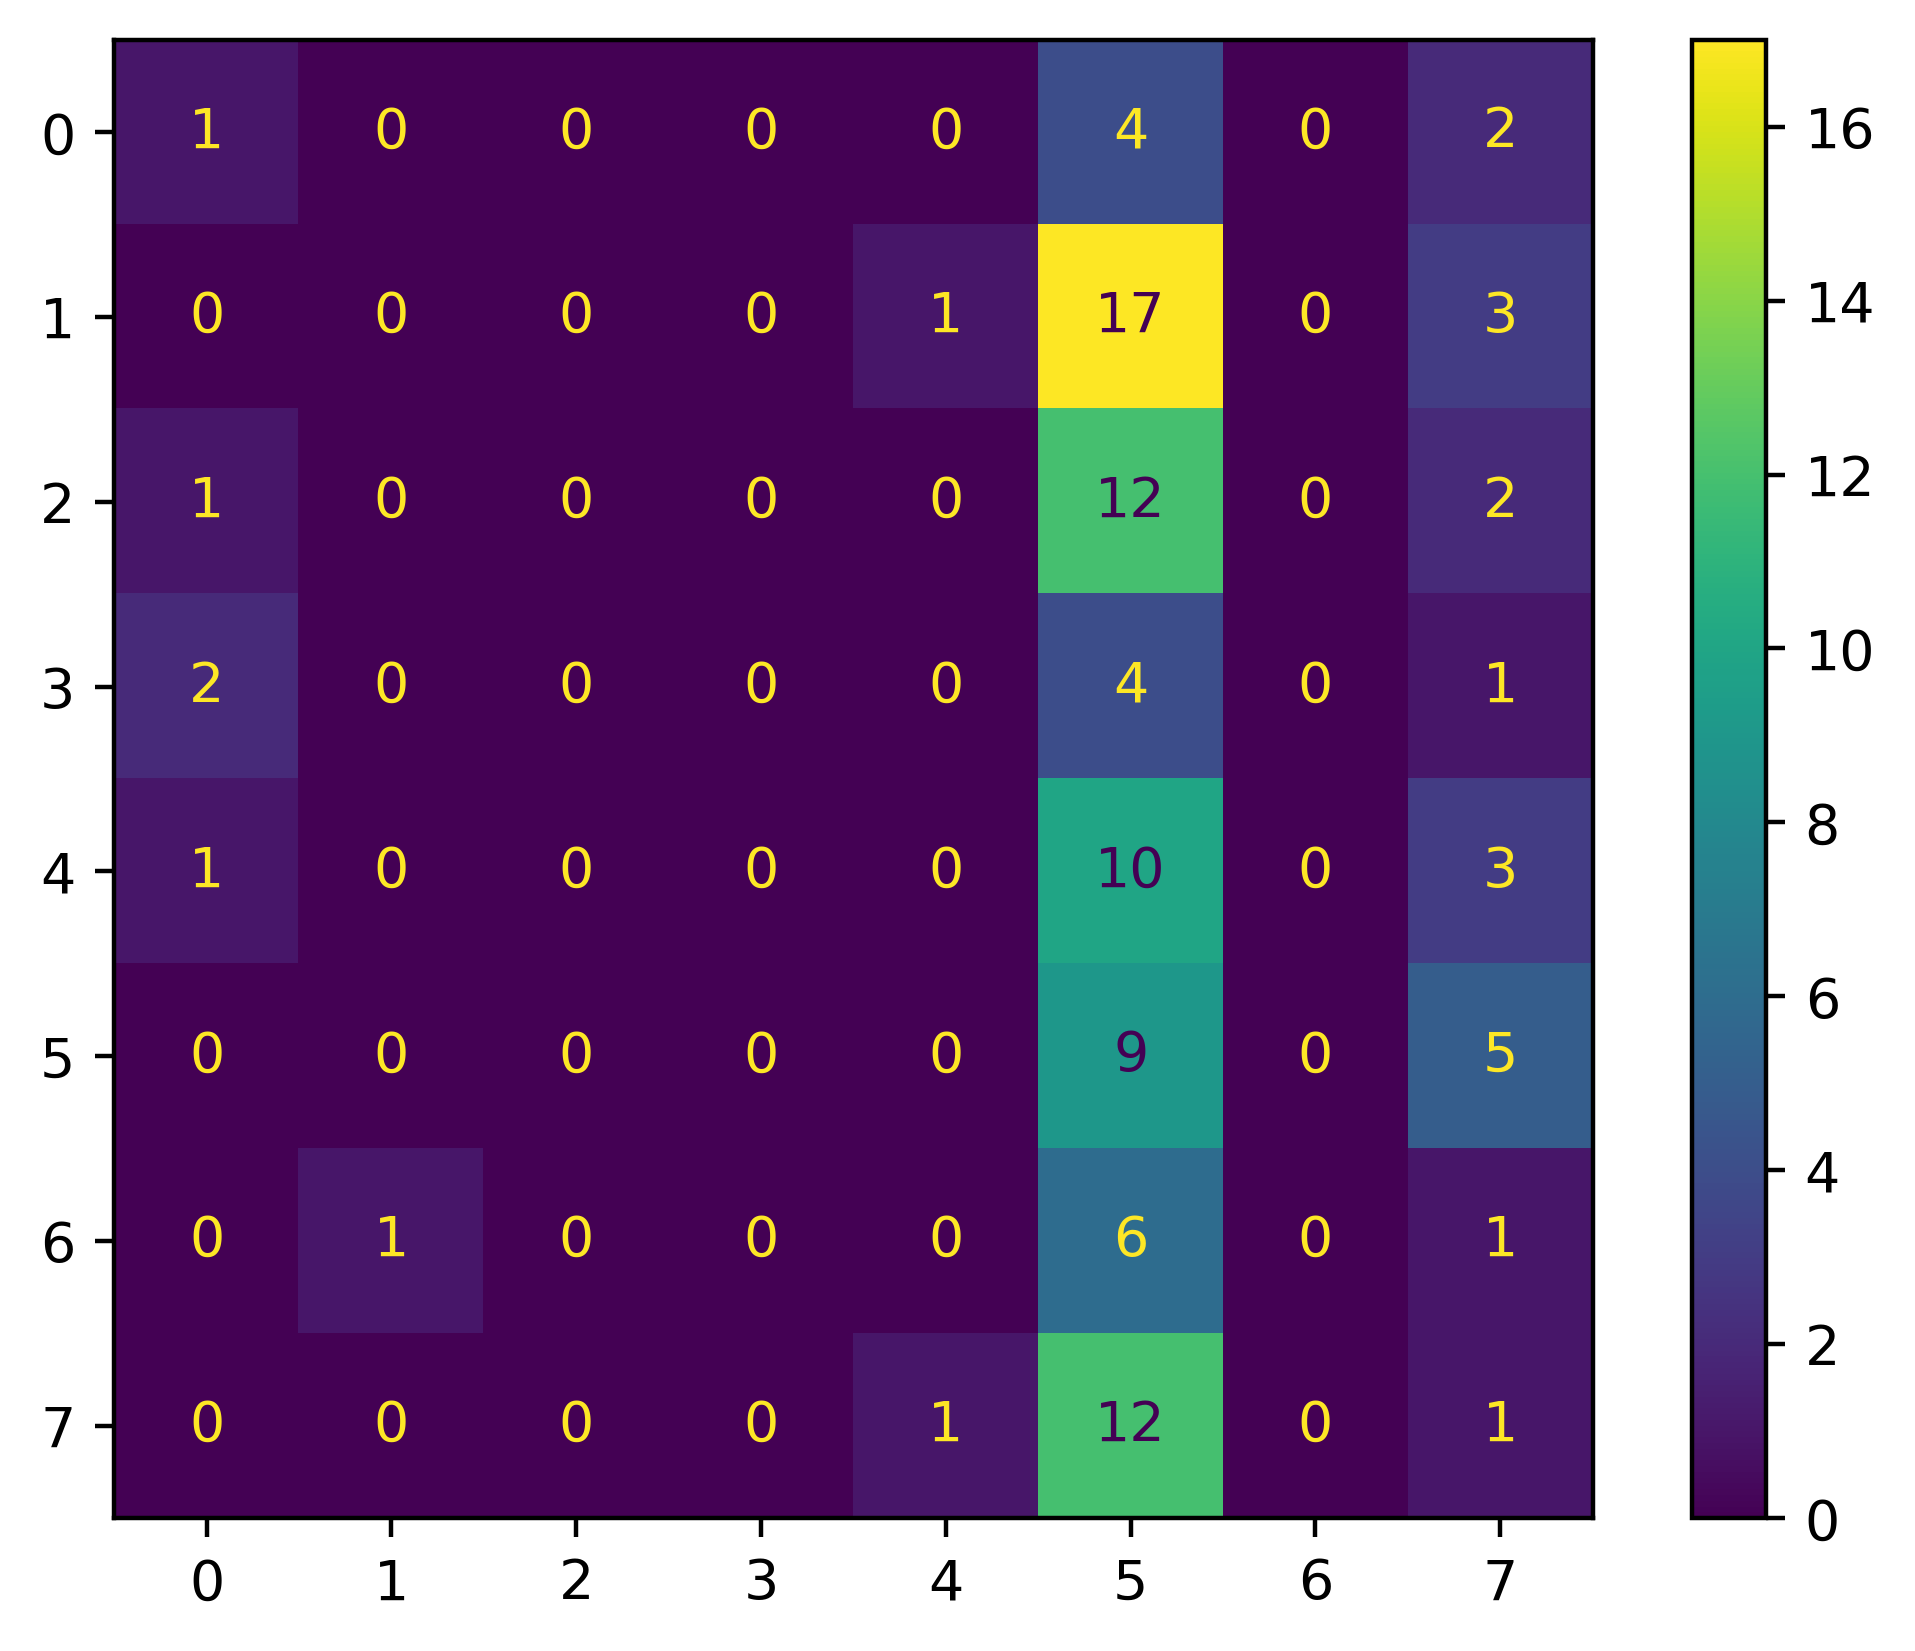

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=it_le.classes_, xticks_rotation=45)


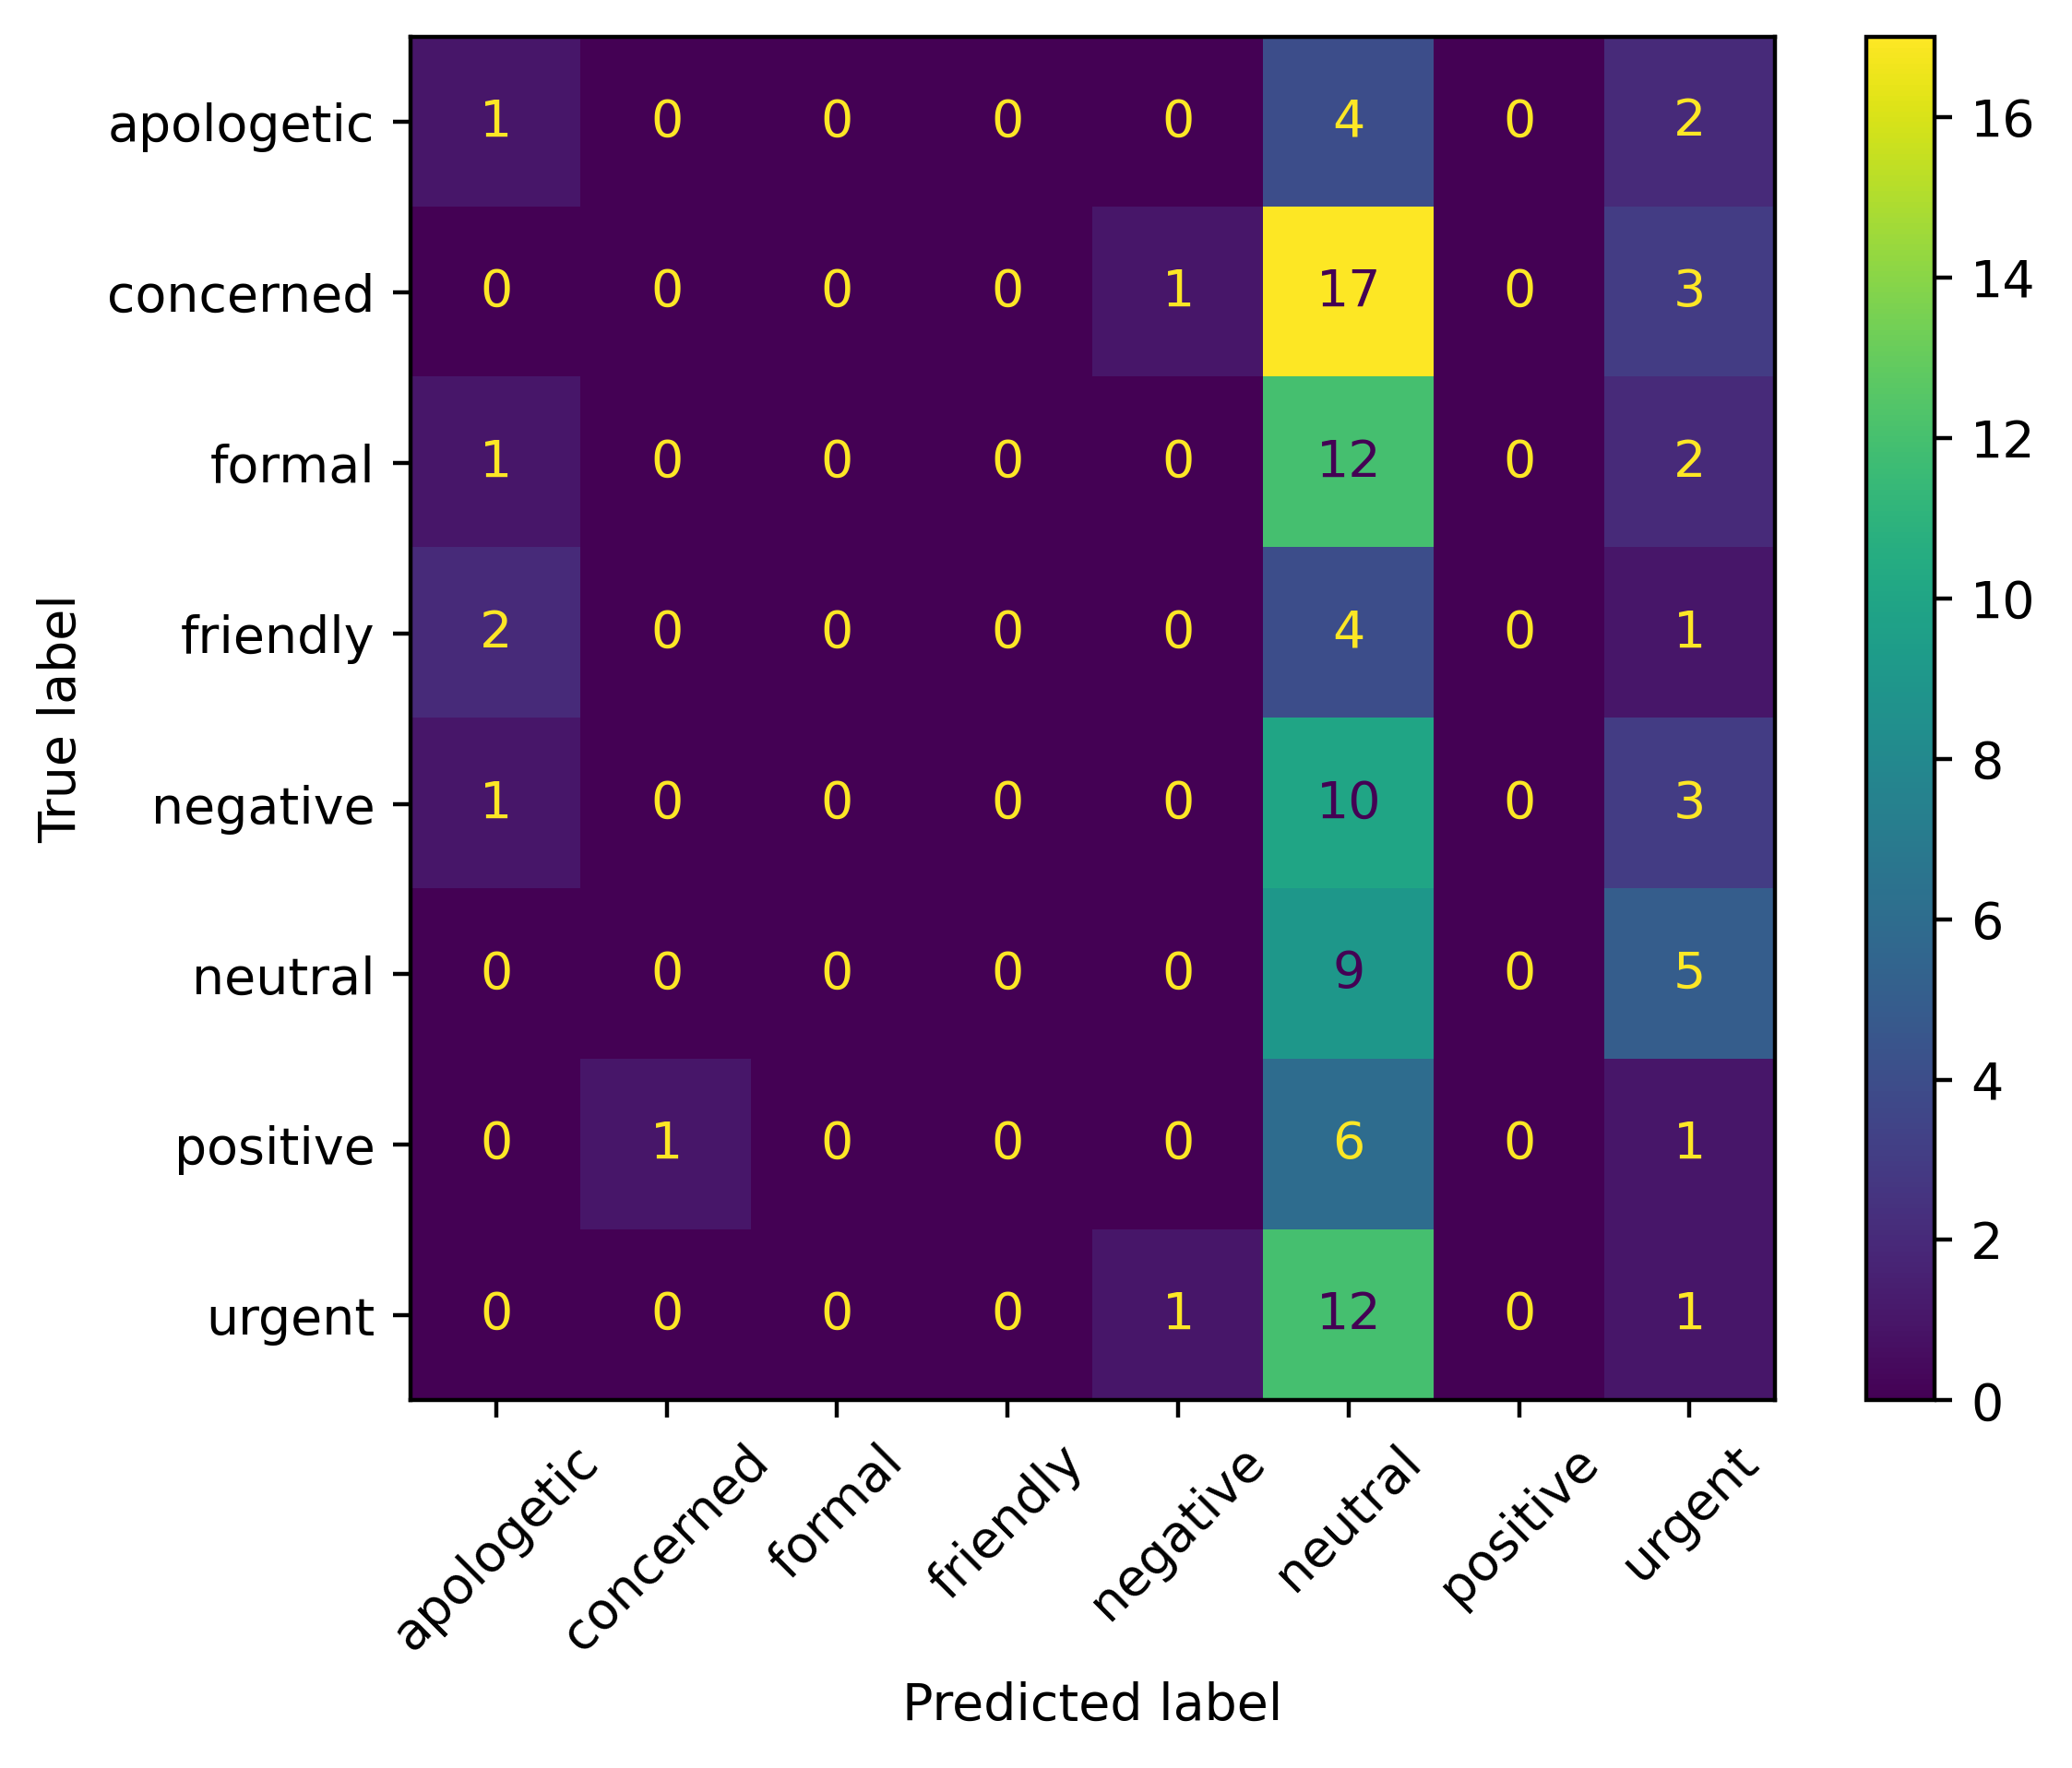

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=st_le.classes_, xticks_rotation=45)


In [ ]:
from transformers import pipeline

# Load your trained pipeline
classifier = pipeline("text-classification", model=trainer_model.model, tokenizer=tokenizer)

# Assuming you used LabelEncoder and it's named 'le'
def predict_intent(text):
    result = classifier(text)[0]
    label_index = int(result['label'].split('_')[-1])  # Get the numeric part from 'LABEL_4'
    class_name = le.inverse_transform([label_index])[0]
    print(f"Predicted Intent: {class_name} (Confidence: {round(result['score'], 2)})")


# Example
predict_intent("The billing department charged me for services I never received.")